# Measuring Volatility, and Trading It

*estimators, forecasts, positions, and what the point estimate omits*

## The question

Volatility is not observed either, and the estimator you choose moves the answer by a
quarter. This notebook measures it five ways and models it three, turns a forecast into a
position with costs attached, and closes on the inference the earlier notebooks did not need —
what to do when you act on a probability rather than an ordering, or owe someone an interval
rather than a number.

### Measuring and forecasting volatility

Volatility is never observed. Every number anyone quotes is an *estimate*, and the choice of
estimator changes the answer by tens of percent — which makes "what is the volatility" a
question with several defensible answers and no single right one.

Three families, answering three different questions:

* **Realized** estimators say what volatility *was*. Close-to-close uses one number a day;
  the range estimators also use the high and low and are roughly four to eight times more efficient
  for it, at the cost of assumptions each successive estimator relaxes.
* **Conditional** models — EWMA, HAR, GARCH — say what it *will be*, by exploiting the one
  robust fact about volatility: it clusters.
* **Implied** volatility says what the market *charges* for it. The gap between implied and
  subsequent realized is the variance risk premium.

Rough volatility, the subject of [What Roughness Claims](what_roughness_claims.ipynb),
is one hypothesis about the dynamics
underneath all of this — a corner of the toolkit, not the frame around it.

### From model to position

A forecast is not a strategy. Between the two sit four decisions that usually matter more than
the forecast itself:

1. **Position construction** — how a score becomes a size. Cross-sectional ranking is
   scale-free and bounded; raw z-scores are neither.
2. **Risk scaling** — a strategy whose volatility wanders is unrunnable whatever its Sharpe.
3. **Costs** — charged on the *change* in position, not the level, which is why a strong
   signal that trades constantly can be worse than a weak one that does not.
4. **Evaluation** — Sharpe hides the path, and the path decides whether anyone can hold the
   position through a bad year.

The signal used below is deliberately weakened to a rank IC of about 0.017 — roughly what a
real cross-sectional equity signal achieves. The planted signal in the synthetic panel is far
stronger than that, and at full strength it produces a Sharpe near 17, which teaches nothing
because no cost level can kill it.

### Inference, calibration, and uncertainty

Parts I and II each needed a particular kind of inference and no more: a point forecast
scored against a benchmark, a ranking scored by rank IC. This notebook covers the inference
they did **not** need — the questions that arrive the moment you act on a probability rather
than an ordering, or quote an interval rather than a number:

* **classification done properly** — imbalance, threshold choice, calibration;
* **categorical encoding that does not leak**, which is the single most dangerous
  transformation in routine use;
* **tuning beyond a grid** — nested cross-validation and Optuna;
* **uncertainty** — quantile regression, when a point forecast is not enough.

The organising idea is the same one that runs through the whole series: every technique here
has a default that is wrong, and knowing which default to change is most of the skill.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
N_DATES     = 1500        # daily bars for the estimator comparison
WINDOW_DAYS = 21          # window for the efficiency experiment
N_SAMPLES   = 200
CLASSIFICATION_SAMPLES = 6000
EWMA_LAMBDA = 0.94        # RiskMetrics daily convention
FORECAST_H  = 40
BARS_PER_YEAR = 252 * 390   # 1-minute bars: annualisation is a per-frequency choice
SEED        = 42
N_ENTITIES   = 200
POSITION_N_DATES = 400 # daily bars for the position/cost section
NOISE_MULT   = 5.0        # weakens the planted signal to a realistic rank IC (~0.017)
COST_BPS     = 1.0
COST_LEVELS  = (0.0, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0)
TARGET_VOL   = 0.10
POSITIVE_RATE = 0.08      # deliberately imbalanced
N_CATEGORIES = 400        # high-cardinality id, for the encoding recipes
N_TRIALS    = 12          # Optuna budget — kept small so the notebook stays under a minute

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
import numpy as np, pandas as pd
from rvlab.data import load_chain_panel, load_panel, load_smile_panel, provenance

ohlc = load_panel(n_entities=1, n_dates=N_DATES, seed=SEED).set_index("Date")
synthetic_returns = np.log(ohlc["Close"]).diff().dropna()

panel = load_chain_panel().sort_values("timestamp_utc")
returns = np.log(panel["underlying_price"]).diff().dropna().reset_index(drop=True)
smile = load_smile_panel("smile_90d", min_dte=7, max_dte=60)

# Under RVLAB_FORCE_SYNTHETIC=1 the chain panel is synthetic too, and the
# clustering contrast below has nothing to contrast. Say so rather than assume.
SOURCE = "synthetic fallback" if provenance(panel).get("synthetic") else "real"
print(f"{len(ohlc):,} synthetic daily bars · {len(returns):,} {SOURCE} SPY 1-min returns "
      f"· {len(smile):,} smile observations")
ohlc[["Open", "High", "Low", "Close", "Volume"]].head(3)

1,500 synthetic daily bars · 2,028 real SPY 1-min returns · 380,857 smile observations


,Open,High,Low,Close,Volume
Date,,,,,
2021-01-04,993.3753,1015.0822,983.9562,1005.9381,101289.0
2021-01-05,1010.1781,1027.8580,996.1761,1027.8580,36796.0
2021-01-06,1014.4798,1022.5489,976.4282,977.0137,237873.0


## Recipes in this notebook

**Measuring and forecasting volatility**

| Recipe | What it does |
|---|---|
| [R8.1](#r8-1) | Compare the five realized-volatility estimators |
| [R8.2](#r8-2) | Measure the efficiency gain properly |
| [R8.3](#r8-3) | See the discretisation bias |
| [R8.4](#r8-4) | EWMA — one parameter, no fitting, a strong baseline |
| [R8.5](#r8-5) | HAR — long memory from three short-memory terms |
| [R8.6](#r8-6) | GARCH(1,1) by maximum likelihood |
| [R8.7](#r8-7) | Forecast, and read the half-life |
| [R8.8](#r8-8) | Score the forecasts against a random walk |
| [R8.9](#r8-9) | Read the implied-volatility term structure |
| [R8.10](#r8-10) | Measure the variance risk premium |
| [R8.11](#r8-11) | Measure volatility clustering, against a control |

**From model to position**

| Recipe | What it does |
|---|---|
| [R8.12](#r8-12) | Turn a score into a position |
| [R8.13](#r8-13) | Standardise within the date, not across the panel |
| [R8.14](#r8-14) | Target a volatility instead of a position size |
| [R8.15](#r8-15) | Cost is charged on the change, not the level |
| [R8.16](#r8-16) | Find the break-even cost |
| [R8.17](#r8-17) | Report three ratios, not one |
| [R8.18](#r8-18) | Read the tearsheet |
| [R8.19](#r8-19) | Attribute P&L to its sources |
| [R8.20](#r8-20) | Walk the strategy forward |
| [R8.21](#r8-21) | The four ways this goes wrong |

**Inference, calibration, and uncertainty**

| Recipe | What it does |
|---|---|
| [R8.22](#r8-22) | Establish what a trivial classifier would score |
| [R8.23](#r8-23) | Choose the threshold from what errors cost |
| [R8.24](#r8-24) | Check calibration, not just ranking |
| [R8.25](#r8-25) | Target-encode inside the folds, never across them |
| [R8.26](#r8-26) | Handle rare and unseen categories |
| [R8.27](#r8-27) | Encode periodic features as a sine/cosine pair |
| [R8.28](#r8-28) | Nest the cross-validation when you tune |
| [R8.29](#r8-29) | Search a large space with Optuna |
| [R8.30](#r8-30) | Predict an interval, not a point |
| [R8.31](#r8-31) | Know which uncertainty you measured |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

Three subjects, one recurring trap: a number that is arithmetically correct and answers a different question than the one asked.

**Python and pandas**

* **The annualisation factor must match the sampling frequency.** 252 on 1-minute data
  understates volatility by a factor of twenty. Carry the factor with the fit rather than
  hard-coding it — that bug is in this notebook's history.
* **`Series.autocorr` drops NaNs silently** and will happily report a correlation computed on
  a different sample than you think.
* **Parameterise a constrained MLE so the constraint cannot be violated.** Optimising GARCH's
  α and β directly wanders into α + β > 1; optimise transformed parameters instead.
* **`predict_proba` column order follows `classes_`.** Assuming column 1 is the positive class
  is right until someone passes labels as strings.
* **Costs apply to the *change* in position, not the level.** `abs(pos).sum()` is a common and
  expensive slip; it is `abs(pos.diff()).sum()`.

**Analysis**

* **The estimator choice moves the answer by 25%.** Range estimators are roughly four to eight times
  more efficient and biased low, because only Yang-Zhang models the overnight gap. Quote which
  one you used.
* **High persistence is not clustering.** A smooth simulated path gives GARCH persistence near
  0.999 with no clustering at all; the autocorrelation of absolute returns is the measure that
  separates them.
* **A Sharpe of 17 is a bug, not a strategy.** A backtest that costs cannot kill is
  demonstrating a leak. The realistic figure here is a rank IC of 0.017 and a break-even cost
  of a few basis points.
* **Naive target encoding leaks provably.** Encoded on a *random* target it still scores
  CV R² = 0.06; the out-of-fold version returns zero, which is the right answer.
* **A prediction interval is not a confidence interval on the mean.** They differ by roughly fifty-fold
  here, and quoting the narrow one where the wide one belongs understates risk by
  exactly that factor.


## Measuring and forecasting volatility

Five realized estimators and three conditional models, measured against each other and against a control that has no volatility clustering in it at all.

## R8.1 · Compare the five realized-volatility estimators
<a id="r8-1"></a>

**Topic** Realized volatility

**Use when** you need a volatility number from price history and want to know how much the choice matters. It matters by 25%.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the three pure-range estimators see only the intraday leg and miss the overnight gap entirely, so they come in **low** on any asset that gaps — which is every equity. Yang-Zhang is the only one that models the gap.

**See also** [R8.2](#r8-2) (why use them anyway) · [R8.3](#r8-3) (the other bias)

In [4]:
from rvlab.models.volatility import estimator_table

estimator_table(ohlc)

,annualized_vol,ratio_to_close_to_close
close_to_close,0.5322,1.0000
parkinson,0.3990,0.7497
garman_klass,0.3851,0.7236
rogers_satchell,0.3847,0.7229
yang_zhang,0.5036,0.9463


The ordering is not arbitrary. Each estimator relaxes an assumption the previous one made: Garman-Klass adds the open and close to Parkinson's range, Rogers-Satchell removes the zero-drift assumption, and Yang-Zhang adds the overnight gap. The ratio column tracks that progression.

In [5]:
ratios = estimator_table(ohlc)["ratio_to_close_to_close"]
for name in ["parkinson", "garman_klass", "rogers_satchell", "yang_zhang"]:
    print(f"  {name:18s} {ratios[name]:.3f} of close-to-close")

  parkinson          0.750 of close-to-close
  garman_klass       0.724 of close-to-close
  rogers_satchell    0.723 of close-to-close
  yang_zhang         0.946 of close-to-close


## R8.2 · Measure the efficiency gain properly
<a id="r8-2"></a>

**Topic** Realized volatility

**Use when** you have heard that Parkinson is five times more efficient and want to check it. The only valid experiment is repeated sampling from the *same* process.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** comparing estimator dispersion **across assets** measures the assets, not the estimators — different names genuinely have different volatilities. Non-overlapping windows from one series is the comparison that isolates sampling error.

**See also** [R8.1](#r8-1) (the levels) · [R8.3](#r8-3) (the bias)

In [6]:
from rvlab.models.volatility import estimator_efficiency

efficiency = estimator_efficiency(ohlc, n_days=WINDOW_DAYS, n_samples=N_SAMPLES, seed=SEED)
efficiency[["mean", "sd", "coefficient_of_variation", "efficiency_vs_close_to_close"]]

,mean,sd,coefficient_of_variation,efficiency_vs_close_to_close
close_to_close,0.5210,0.0889,0.1707,1.0000
parkinson,0.3976,0.0313,0.0786,4.7148
garman_klass,0.3853,0.0231,0.0600,8.0934
rogers_satchell,0.3854,0.0270,0.0702,5.9142
yang_zhang,0.5041,0.0404,0.0802,4.5274


So the trade is explicit: the range estimators are **biased but precise**, close-to-close is **unbiased but noisy**. On a 21-day window that noise dominates, which is why range estimators are standard for short-horizon work despite the bias.

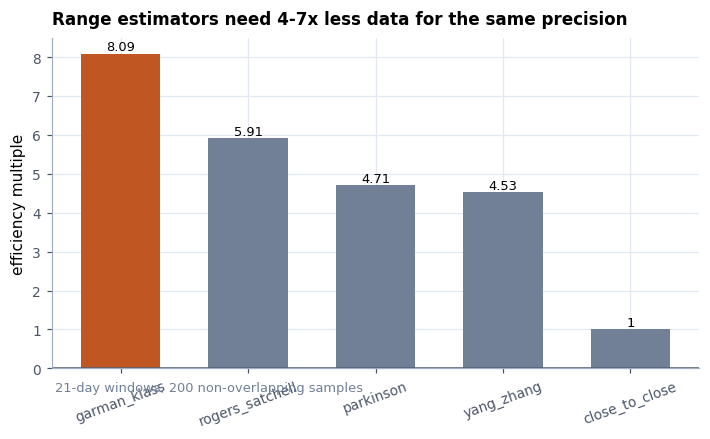

In [7]:
from rvlab.plotting import annotated_bar

annotated_bar(efficiency["efficiency_vs_close_to_close"], ylabel="efficiency multiple",
              title="Range estimators need 4-7x less data for the same precision",
              note=f"{WINDOW_DAYS}-day windows, {N_SAMPLES} non-overlapping samples");

## R8.3 · See the discretisation bias
<a id="r8-3"></a>

**Topic** Realized volatility

**Use when** you want to know why published range estimates run low. A daily bar is built from finitely many observations and cannot see the true continuous maximum.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the bias shrinks as the bar's underlying sampling gets finer, and it never reaches zero. On real data you cannot fix it — but you can know its sign, which is always **downward**.

**See also** [R8.1](#r8-1) (levels) · [R8.2](#r8-2) (efficiency)

In [8]:
from rvlab.data.panel import synthetic_equity_panel
import rvlab.data.panel as panel_module
from rvlab.models.volatility import estimator_table

rows = []
original = panel_module._intraday_ohlc
for steps in (6, 24, 78, 195):
    panel_module._intraday_ohlc = (
        lambda r, c, rng, gap_share=0.35, n=steps: original(r, c, rng, gap_share, n))
    bars = synthetic_equity_panel(n_entities=1, n_dates=800, seed=SEED)
    ratios = estimator_table(bars)["ratio_to_close_to_close"]
    rows.append({"intraday_steps": steps, "parkinson": ratios["parkinson"],
                 "yang_zhang": ratios["yang_zhang"]})
panel_module._intraday_ohlc = original
pd.DataFrame(rows)

,intraday_steps,parkinson,yang_zhang
0,6,0.6336,0.8116
1,24,0.7129,0.8888
2,78,0.7537,0.9306
3,195,0.7828,0.9619


Both estimators climb toward their asymptote as the bar is sampled more finely. The gap that remains for Parkinson at every step count is the overnight gap it structurally cannot see.

In [9]:
table = pd.DataFrame(rows).set_index("intraday_steps")
print(f"Parkinson  {table['parkinson'].iloc[0]:.3f} -> {table['parkinson'].iloc[-1]:.3f}")
print(f"Yang-Zhang {table['yang_zhang'].iloc[0]:.3f} -> {table['yang_zhang'].iloc[-1]:.3f}")

Parkinson  0.634 -> 0.783
Yang-Zhang 0.812 -> 0.962


## R8.4 · EWMA — one parameter, no fitting, a strong baseline
<a id="r8-4"></a>

**Topic** Conditional volatility

**Use when** you need a conditional volatility estimate today and do not want to fit anything. RiskMetrics' exponentially weighted variance is the default for good reason.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** `lam=0.94` is the daily convention and implies an 11-day half-life. Any GARCH you fit should be compared against this — a fitted model that cannot beat a one-parameter exponential average has not earned its parameters.

**See also** [R8.5](#r8-5) (HAR) · [R8.6](#r8-6) (GARCH)

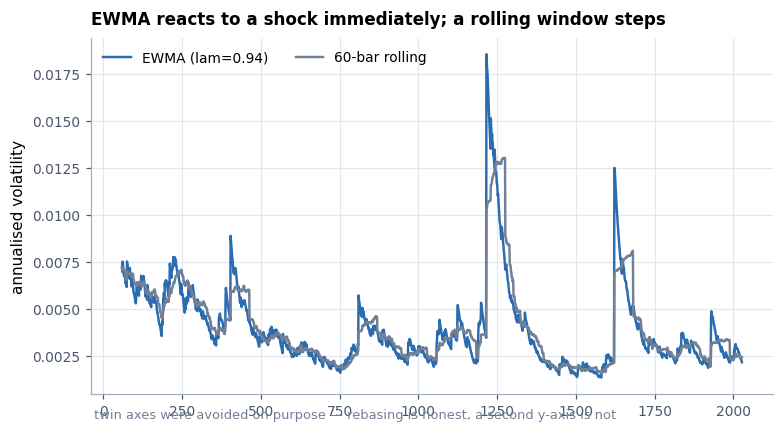

In [10]:
from rvlab.models.volatility import ewma_vol
from rvlab.plotting import multi_series

ewma = ewma_vol(returns, lam=EWMA_LAMBDA)
rolling = returns.rolling(60).std() * np.sqrt(252)
comparison = pd.DataFrame({"EWMA (lam=0.94)": ewma, "60-bar rolling": rolling}).dropna()
multi_series(comparison, comparison.columns, rebase=False, ylabel="annualised volatility",
             title="EWMA reacts to a shock immediately; a rolling window steps");

The difference is what happens when a shock leaves the fixed window: its rolling weight drops discontinuously to zero, an artefact of the estimator rather than the market. EWMA's weight decays smoothly.

In [11]:
import numpy as np, pandas as pd

half_life = np.log(0.5) / np.log(EWMA_LAMBDA)
print(f"EWMA half-life at lambda={EWMA_LAMBDA}: {half_life:.1f} days")
ages = np.array([0, 20, 59, 60])
weights = pd.DataFrame({"age": ages,
                        "60-bar rolling weight": (ages < 60) / 60,
                        "EWMA weight": (1 - EWMA_LAMBDA) * EWMA_LAMBDA ** ages})
weights.set_index("age")

EWMA half-life at lambda=0.94: 11.2 days


,60-bar rolling weight,EWMA weight
age,,
0,0.0167,0.0600
20,0.0167,0.0174
59,0.0167,0.0016
60,0.0000,0.0015


## R8.5 · HAR — long memory from three short-memory terms
<a id="r8-5"></a>

**Topic** Conditional volatility

**Use when** forecasting realized variance. Corsi's HAR regresses tomorrow's variance on its own averages over a day, a week and a month.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** every regressor must be **shifted** so it is known before the target. Unshifted, HAR reports an R² above 0.9 and forecasts nothing — this is the single most common way the model is misimplemented.

**See also** [R8.4](#r8-4) (EWMA) · [R3.3](forecasting_the_smile.ipynb#r3-3) (grouped shifts)

In [12]:
from rvlab.models.volatility import har_rv

realized_variance = (returns ** 2).rolling(30).mean().dropna() * 252 * 390
model, design = har_rv(realized_variance)
print(model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   7.02e-05      2.825      0.005    6.07e-05       0.000
daily          1.0044      0.021     47.859      0.000       0.963       1.046
weekly        -0.0065      0.026     -0.250      0.802      -0.058       0.045
monthly       -0.0232      0.012     -1.984      0.047      -0.046      -0.000


Read the coefficients rather than assuming their signs. The daily term dominates this fit; weekly and monthly terms are small and can be negative. Their sum describes persistence, while the multi-horizon decomposition remains a short-memory alternative to a rough-volatility explanation.

In [13]:
print(f"HAR R2 = {model.rsquared:.4f}")
print(f"sum of the three horizon coefficients: "
      f"{model.params.drop('const', errors='ignore').sum():.4f}  (near 1 = near unit root)")

HAR R2 = 0.9606
sum of the three horizon coefficients: 0.9746  (near 1 = near unit root)


## R8.6 · GARCH(1,1) by maximum likelihood
<a id="r8-6"></a>

**Topic** Conditional volatility

**Use when** you want a conditional variance model with an explicit likelihood, mean reversion and a forecastable path. The recursion is three terms: a long-run level, the latest surprise, and yesterday's variance.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** two things. Constrain `alpha + beta < 1`, without which the process has no finite unconditional variance and a boundary fit is a warning rather than a result. And pass the right `annualize`: these are 1-minute bars, so it is 252x390, not 252. The wrong factor understates annual volatility by about twentyfold, and the result can still look superficially plausible.

**See also** [R8.7](#r8-7) (forecasting) · [R8.4](#r8-4) (the baseline to beat)

In [14]:
from rvlab.models.volatility import garch11

fit = garch11(returns, annualize=BARS_PER_YEAR)
print(f"{SOURCE} SPY 1-minute returns:")
print(fit)

real SPY 1-minute returns:
GARCH(1,1)  omega=9.947e-10  alpha=0.0491  beta=0.9470
  persistence 0.9961 · half-life 176.5 periods · long-run vol 0.1579 (annualised by 98,280)


Now the same fit on the **synthetic** bars, which were built from independent daily factors and therefore contain no clustering at all. The estimator says so: persistence collapses and the half-life falls below a day, which is GARCH's way of reporting that there is nothing to model.

Running a model on data you know to be null is the cheapest way to learn what its output looks like when it has found nothing.

In [15]:
null_fit = garch11(synthetic_returns)          # daily bars: the 252 default is right
print("synthetic bars (no clustering by construction):")
print(null_fit)

synthetic bars (no clustering by construction):
GARCH(1,1)  omega=7.761e-04  alpha=0.0524  beta=0.2567
  persistence 0.3091 · half-life 0.6 periods · long-run vol 0.5320 (annualised by 252)


And validated against data whose parameters were set deliberately, which is what makes the hand-written likelihood trustworthy.

In [16]:
rng = np.random.default_rng(SEED)
n, omega, alpha, beta = 4000, 2e-6, 0.09, 0.88
eps = np.zeros(n); s2 = np.zeros(n); s2[0] = omega / (1 - alpha - beta)
for t in range(1, n):
    s2[t] = omega + alpha * eps[t - 1] ** 2 + beta * s2[t - 1]
    eps[t] = rng.normal(0, np.sqrt(s2[t]))

check = garch11(pd.Series(eps))
print(f"true persistence {alpha + beta:.4f} · recovered {check.persistence:.4f} "
      f"· error {abs(check.persistence - alpha - beta):.4f}")

true persistence 0.9700 · recovered 0.9635 · error 0.0065


## R8.7 · Forecast, and read the half-life
<a id="r8-7"></a>

**Topic** Conditional volatility

**Use when** you need a volatility forecast over a horizon. GARCH decays geometrically toward its long-run level at rate `persistence`.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** R8.6 — run those first. This recipe builds on what they define.

**Gotchas** the half-life is the number to report, not the persistence itself — 0.95 and 0.99 look similar and imply half-lives of 14 and 69 **periods**. Periods are bars, not days: always report the sampling frequency and convert bars to trading time.

**See also** [R8.6](#r8-6) (the fit) · [R8.8](#r8-8) (does it beat a random walk?)

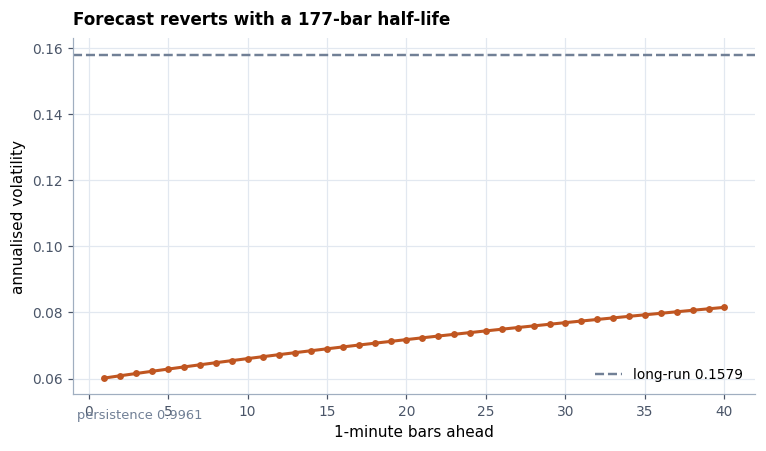

In [17]:
from rvlab.models.volatility import garch_forecast
from rvlab.plotting import line_with_reference

path = garch_forecast(fit, last_return=float(returns.iloc[-1]),
                      last_var=float(fit.conditional_vol.iloc[-1] ** 2 / BARS_PER_YEAR),
                      horizon=FORECAST_H)
line_with_reference(path, reference=fit.long_run_vol,
                    title=f"Forecast reverts with a {fit.half_life:.0f}-bar half-life",
                    xlabel="1-minute bars ahead", ylabel="annualised volatility",
                    note=f"persistence {fit.persistence:.4f}");

## R8.8 · Score the forecasts against a random walk
<a id="r8-8"></a>

**Topic** Forecast evaluation

**Use when** before believing any conditional model. The benchmark is 'tomorrow's volatility equals today's' — and it is much harder to beat than it sounds.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** R8.4, R8.6 — run those first. This recipe builds on what they define.

**Gotchas** score on **out-of-sample** predictions and on variance rather than volatility, since that is what the models actually parameterise. A model that cannot beat the random walk has not earned the parameters it costs.

**See also** [R8.4](#r8-4) (EWMA) · [R3.17](forecasting_the_smile.ipynb#r3-17) (skill scores)

In [18]:
from rvlab.evaluate import rmse
from rvlab.models.volatility import ewma_vol

split = int(0.70 * len(returns))
train_returns, test_returns = returns.iloc[:split], returns.iloc[split:]
oos_fit = garch11(train_returns, annualize=BARS_PER_YEAR)
state_var = float(oos_fit.conditional_vol.iloc[-1] ** 2 / BARS_PER_YEAR)
long_run = oos_fit.omega / (1 - oos_fit.persistence)
garch_oos = {}
for ts, observed_return in test_returns.items():
    next_var = oos_fit.omega + oos_fit.alpha * observed_return ** 2 + oos_fit.beta * state_var
    path, forecast_var = [next_var], next_var
    for _ in range(29):
        forecast_var = long_run + oos_fit.persistence * (forecast_var - long_run)
        path.append(forecast_var)
    garch_oos[ts], state_var = np.mean(path) * BARS_PER_YEAR, next_var
target = (returns ** 2).rolling(30).mean().shift(-30) * BARS_PER_YEAR
candidates = pd.DataFrame({
    "random walk": (returns ** 2).rolling(30).mean() * BARS_PER_YEAR,
    "EWMA": ewma_vol(returns, EWMA_LAMBDA, BARS_PER_YEAR) ** 2,
    "GARCH": pd.Series(garch_oos),
}).loc[test_returns.index].dropna()
scored = target.reindex(candidates.index).dropna()
candidates = candidates.reindex(scored.index)
pd.Series({k: rmse(scored, candidates[k]) for k in candidates}, name="OOS RMSE").to_frame()

,OOS RMSE
random walk,0.0108
EWMA,0.0107
GARCH,0.0092


Expressed as skill against the random walk, which is the only form that says whether the extra machinery paid for itself.

In [19]:
base = rmse(scored, candidates["random walk"])
for name in candidates.columns:
    print(f"  {name:14s} skill vs random walk: "
          f"{1 - rmse(scored, candidates[name]) / base:+.4f}")

  random walk    skill vs random walk: +0.0000
  EWMA           skill vs random walk: +0.0109
  GARCH          skill vs random walk: +0.1492


## R8.9 · Read the implied-volatility term structure
<a id="r8-9"></a>

**Topic** Implied volatility

**Use when** you have an option panel. Average implied volatility by maturity — upward sloping in calm markets, inverted in stressed ones.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** pool by maturity *bucket*, not by expiry date. Expiry dates roll continuously, so grouping on them gives you a hundred groups of a few observations each and no term structure at all.

**See also** [R8.10](#r8-10) (the premium) · [R1.23](the_volatility_surface.ipynb#r1-23) (one cross-section)

In [20]:
from rvlab.models.volatility import vol_term_structure

vol_term_structure(smile)

,mean,std,count
days_to_expiry,,,
"(0, 10]",0.1304,0.0253,94885
"(10, 21]",0.1315,0.0249,130885
"(21, 35]",0.1376,0.0201,71338
"(35, 60]",0.1425,0.0180,83749


Plotted, with the dispersion — the spread matters as much as the level, because it is what a term-structure trade is exposed to.

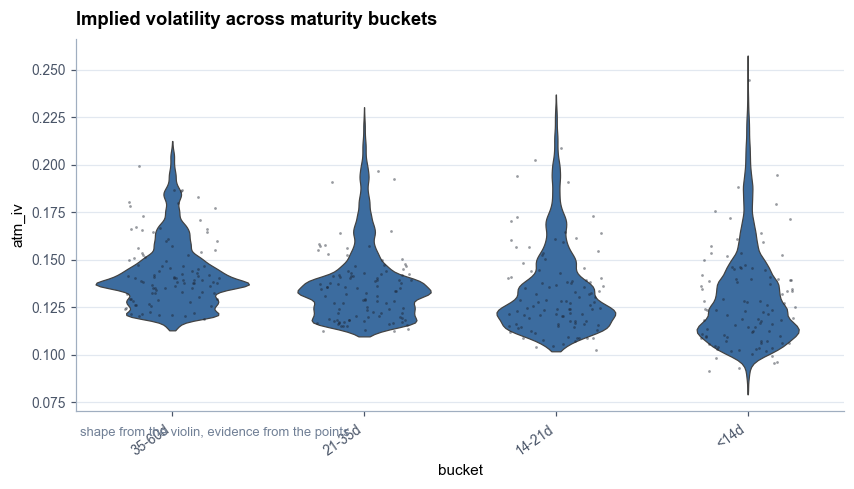

In [21]:
from rvlab.plotting import violin_strip

bucketed = smile.assign(bucket=pd.cut(smile["T"] * 365, [0, 14, 21, 35, 60],
                                      labels=["<14d", "14-21d", "21-35d", "35-60d"]).astype(str))
violin_strip(bucketed, "atm_iv", "bucket",
             title="Implied volatility across maturity buckets");

## R8.10 · Measure the variance risk premium
<a id="r8-10"></a>

**Topic** Implied volatility

**Use when** testing whether implied variance exceeds subsequent realized variance. The difference is a candidate variance risk premium; measure its sign rather than assuming it.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** both inputs must be **volatilities**, annualised the same way. This project's `atm_total_var` is a *total* variance (σ²T) and must be divided by T first — mixing the two is the unit error the project README flags as limitation 8.5.

**See also** [R8.9](#r8-9) (term structure) · [R8.13](measuring_and_trading_volatility.ipynb#r8-13) (trading it)

In [22]:
from rvlab.data import load_chain_panel
from rvlab.models.volatility import variance_risk_premium

panel = load_chain_panel()
implied = np.sqrt(panel["vix_varswap"].clip(lower=0))
realized = panel["rv5_ann"].clip(lower=0)
vrp = variance_risk_premium(implied, realized).dropna()

print(f"mean VRP {vrp.mean():+.5f} · positive on {(vrp > 0).mean():.1%} of bars")
print(f"in volatility points: implied {implied.mean():.4f} vs realized {realized.mean():.4f}")

mean VRP +0.01161 · positive on 93.6% of bars
in volatility points: implied 0.1333 vs realized 0.0666


> ⚠️ **What this is not:** the sign is not guaranteed by the definition. When the average premium is positive it can still be compensation for left-tail risk; when it is negative, this sample does not establish the usual positive-premium claim.

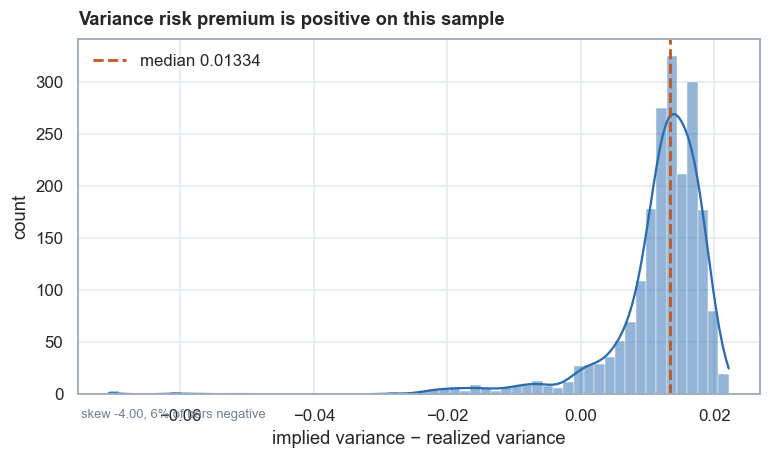

In [23]:
from rvlab.plotting import hist_kde

vrp_sign = "positive" if vrp.mean() > 0 else "negative"
hist_kde(vrp, xlabel="implied variance − realized variance",
         title=f"Variance risk premium is {vrp_sign} on this sample",
         note=f"skew {vrp.skew():+.2f}, {(vrp < 0).mean():.0%} of bars negative");

## R8.11 · Measure volatility clustering, against a control
<a id="r8-11"></a>

**Topic** Regimes

**Use when** before fitting any conditional model. Clustering is the property those models exist to exploit — so measure whether the series has it, and compare against data you know does not.

**Inputs** `ohlc` (daily OHLC bars) or `smile` (the option panel), as named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** **expanding, not full-sample.** A tercile computed over the whole history knows the future, and conditioning on it is the leak that makes stress-period results look wonderful — see [R4.12](when_a_result_is_real.ipynb#r4-12) for what that costs.

**See also** [R8.6](#r8-6) (GARCH) · [R4.12](when_a_result_is_real.ipynb#r4-12) (conditioning honestly)

In [24]:
from rvlab.models.volatility import ewma_vol, garch11, volatility_regimes

def clustering_profile(series, label, periods=BARS_PER_YEAR):
    r = pd.Series(series).dropna().reset_index(drop=True)
    regimes = volatility_regimes(ewma_vol(r, EWMA_LAMBDA)).dropna()
    nxt = r.abs().shift(-1)
    joined = pd.DataFrame({"regime": regimes, "next_abs": nxt}).dropna()
    means = joined.groupby("regime")["next_abs"].mean()
    return {"series": label,
            "abs_return_autocorr": round(r.abs().autocorr(1), 3),
            "stressed_over_calm": round(means.get("stressed", np.nan)
                                        / means.get("calm", np.nan), 2),
            "garch_persistence": round(garch11(r, annualize=periods).persistence, 3),
            "annualised_by": periods}

pd.DataFrame([clustering_profile(returns, f"{SOURCE} SPY 1-minute"),
              clustering_profile(synthetic_returns, "synthetic (null control)", periods=252)])

,series,abs_return_autocorr,stressed_over_calm,garch_persistence,annualised_by
0,real SPY 1-minute,0.157,1.85,0.996,98280
1,synthetic (null control),0.042,1.06,0.309,252


Note the annualisation column. Both fits are correct; they describe data sampled at different frequencies, and the long-run level is only comparable once each is annualised by its own number of periods per year.

The contrast is the point, and it needs the real panel. Under `RVLAB_FORCE_SYNTHETIC=1` the top row loses its clustering — autocorrelation near zero, ratio below one — while GARCH still reports persistence near 0.999. That is worth seeing: **high persistence is not by itself evidence of clustering**, only of a slowly-varying conditional variance, which a smooth simulated path also has. Real returns cluster: after a stressed bar the next absolute move is nearly twice as large as after a calm one, and GARCH persistence sits just below one. The synthetic control shows neither, because nothing in its construction links one day's volatility to the next.

That gap is the entire economic content of EWMA, HAR and GARCH — and it is why those models add nothing on the synthetic panel and a great deal on real data.

In [25]:
profile = clustering_profile(returns, SOURCE)
print(f"After a stressed bar, the next absolute move is "
      f"{profile['stressed_over_calm']:.2f}x the size it is after a calm one.")
print(f"GARCH persistence {profile['garch_persistence']:.3f} — interpret it only "
      f"beside the clustering statistics and the null control.")

After a stressed bar, the next absolute move is 1.85x the size it is after a calm one.
GARCH persistence 0.996 — interpret it only beside the clustering statistics and the null control.


## From model to position

Signal to position to P&L, with costs applied to the change rather than the level — and the break-even cost reported instead of the Sharpe at an assumed one.

Its data cell binds `ic`, `panel`, `raw`, `rng`, `signal`.

In [26]:
import numpy as np, pandas as pd
from rvlab.data import load_panel
from rvlab.evaluate.ranking import daily_rank_ic
from rvlab.features import build_panel_features

panel = build_panel_features(load_panel(n_entities=N_ENTITIES, n_dates=POSITION_N_DATES, seed=SEED))
panel = panel.dropna(subset=["Target", "ret_1d"]).reset_index(drop=True)

rng = np.random.default_rng(SEED)
raw = -panel["ret_1d"]                                   # short-term reversal
signal = raw + rng.normal(0, NOISE_MULT * raw.std(), len(raw))

ic = daily_rank_ic(panel.assign(Prediction=signal))
print(f"{len(panel):,} rows · {panel['Date'].nunique()} dates · "
      f"rank IC {ic.mean():+.4f} (realistic for a cross-sectional equity signal)")

79,326 rows · 397 dates · rank IC +0.0171 (realistic for a cross-sectional equity signal)


## R8.12 · Turn a score into a position
<a id="r8-12"></a>

**Topic** Position construction

**Use when** the first decision after the model. Three methods, and the choice changes the risk profile more than the model does.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** **rank** is scale-free, bounded and immune to a single extreme score — the default for a cross-sectional book. **z-score** keeps conviction but needs a cap or one outlier takes the whole book. **sign** throws away conviction entirely and is surprisingly hard to beat.

**See also** [R8.13](#r8-13) (the common error) · [R8.14](#r8-14) (sizing)

In [27]:
from rvlab.strategy import signal_to_position

methods = {m: signal_to_position(signal, dates=panel["Date"], method=m, gross_target=1.0)
           for m in ("rank", "zscore", "sign")}
pd.DataFrame({m: {"min": p.min(), "max": p.max(), "mean_abs": p.abs().mean(),
                  "gross_per_date": p.abs().groupby(panel["Date"].to_numpy()).sum().mean()}
              for m, p in methods.items()}).round(4)

,rank,zscore,sign
min,-0.0100,-0.0201,-0.0051
max,0.0101,0.0199,0.0051
mean_abs,0.0050,0.0050,0.0050
gross_per_date,1.0000,1.0000,1.0000


Why rank is robust: plant one absurd score and see which method survives it.

In [28]:
poisoned = signal.copy()
poisoned.iloc[0] = 1e6
for m in ("rank", "zscore"):
    clean = signal_to_position(signal, dates=panel["Date"], method=m)
    dirty = signal_to_position(poisoned, dates=panel["Date"], method=m)
    moved = (clean - dirty).abs().gt(0.05).sum()
    print(f"  {m:8s} one extreme score moved {moved:,} positions")

  rank     one extreme score moved 1 positions


  zscore   one extreme score moved 189 positions


## R8.13 · Standardise within the date, not across the panel
<a id="r8-13"></a>

**Topic** Position construction

**Use when** any cross-sectional book. The scores must be compared against *the other names on the same day*, not against the whole history.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12

**Gotchas** pooling standardises across entities **and** time at once, so a calm day's best name gets a smaller position than a volatile day's worst. It is not a subtle difference — the two position vectors are genuinely different strategies.

**See also** [R8.12](#r8-12) (the methods) · [R5.11](the_cross_section.ipynb#r5-11) (the same idea for features)

In [29]:
from rvlab.strategy import pnl_series, signal_to_position, strategy_metrics

# Both normalised to the same gross exposure per date, so the comparison is about
# *where* the standardisation happened, not about book size.
per_date = signal_to_position(signal, dates=panel["Date"], method="zscore",
                              gross_target=1.0)
pooled = signal_to_position(signal, method="zscore")
pooled = pooled / pooled.abs().groupby(panel["Date"].to_numpy()).transform("sum")

comparison = {}
for name, pos in {"per-date": per_date, "pooled": pooled}.items():
    pnl = pnl_series(pos, panel["Target"], cost_bps=COST_BPS, dates=panel["Date"])
    comparison[name] = strategy_metrics(pnl["net"])
pd.DataFrame(comparison).loc[["annualised_return", "annualised_vol", "sharpe",
                              "max_drawdown"]].round(4)

,per-date,pooled
annualised_return,0.0974,0.1215
annualised_vol,0.0338,0.0440
sharpe,2.8843,2.7637
max_drawdown,0.0217,0.0238


## R8.14 · Target a volatility instead of a position size
<a id="r8-14"></a>

**Topic** Risk scaling

**Use when** the strategy's realised volatility drifts with the market's. Scaling by a trailing estimate of the strategy's own volatility keeps the risk roughly constant.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12

**Gotchas** two things. The estimate must be **shifted** so today's scale does not use today's return — without that the target is met exactly and the backtest is fiction. And cap the leverage: as the volatility estimate falls the implied leverage rises without bound, which concentrates the worst losses in the calm periods that precede shocks.

**See also** [R8.13](#r8-13) (position construction) · [R8.17](#r8-17) (measuring the result)

In [30]:
from rvlab.strategy import pnl_series, strategy_metrics, vol_target

daily = pnl_series(methods["rank"], panel["Target"], cost_bps=COST_BPS,
                   dates=panel["Date"])
plain = daily["net"]

# The "position" is a unit holding of the strategy itself; vol_target returns the
# scale to apply, already shifted so it uses only past returns.
unit = pd.Series(1.0, index=plain.index)
scale = vol_target(unit, plain, target_vol=TARGET_VOL, lookback=60)
targeted = (scale * plain).dropna()

pd.DataFrame({"unscaled": strategy_metrics(plain.loc[targeted.index]),
              "vol-targeted": strategy_metrics(targeted)}
             ).loc[["annualised_return", "annualised_vol", "sharpe", "max_drawdown"]].round(4)

,unscaled,vol-targeted
annualised_return,0.0894,0.2661
annualised_vol,0.0311,0.0902
sharpe,2.8743,2.9514
max_drawdown,0.0167,0.0388


## R8.15 · Cost is charged on the change, not the level
<a id="r8-15"></a>

**Topic** Costs

**Use when** always. Holding a position is free; changing it is not. This single fact decides which signals are tradeable.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12, R8.14

**Gotchas** a signal with a high hit rate and high turnover can lose to a weaker, stickier one. The quantity to watch is turnover per period — not the number of trades, which is the same thing badly measured.

**See also** [R8.16](#r8-16) (the break-even) · [R4.17](when_a_result_is_real.ipynb#r4-17) (a cost sweep)

In [31]:
from rvlab.strategy import apply_costs

held = pd.Series([1.0] * 20)
flipped = pd.Series([1.0, -1.0] * 10)
for name, path in {"hold for 20 periods": held, "flip every period": flipped}.items():
    costs = apply_costs(path, cost_bps=10.0)
    print(f"  {name:22s} turnover {costs['turnover'].sum():5.1f} · "
          f"cost {costs['cost'].sum():.4f}")

  hold for 20 periods    turnover   1.0 · cost 0.0010
  flip every period      turnover  39.0 · cost 0.0390


On this provenance-tagged demonstration book, turnover is what the cost bill is proportional to.

In [32]:
print(f"mean turnover per date: {daily['turnover'].mean():.3f}")
print(f"total cost at {COST_BPS:.0f}bps: {daily['cost'].sum():.4f} "
      f"against gross P&L {daily['gross'].sum():.4f} "
      f"({daily['cost'].sum() / daily['gross'].sum():.1%} of it)")

mean turnover per date: 1.335
total cost at 1bps: 0.0530 against gross P&L 0.1938 (27.4% of it)


## R8.16 · Find the break-even cost
<a id="r8-16"></a>

**Topic** Costs

**Use when** before claiming a strategy works. The number that matters is not the Sharpe at your assumed cost — it is the cost level at which the strategy stops making money.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12

**Gotchas** if the break-even is below what you actually pay, there is no strategy, however good the in-sample Sharpe. Report the whole curve: a single cost assumption silently picks the winner between two candidates.

**See also** [R8.15](#r8-15) (where cost comes from) · [R8.17](#r8-17) (metrics)

In [33]:
from rvlab.strategy import break_even_cost, cost_sweep

sweep = cost_sweep(methods["rank"], panel["Target"], cost_levels=COST_LEVELS,
                   dates=panel["Date"])
sweep.round(4)

,cost_bps,sharpe,annualised_return,mean_turnover
0,0.0,3.9562,0.1230,1.3351
1,1.0,2.8743,0.0894,1.3351
2,2.0,1.7923,0.0557,1.3351
3,5.0,-1.4546,-0.0452,1.3351
4,10.0,-6.8668,-0.2134,1.3351
5,20.0,-17.6809,-0.5499,1.3351
6,50.0,-49.7801,-1.5592,1.3351


Plotted, with the break-even marked — the point where the curve crosses zero.

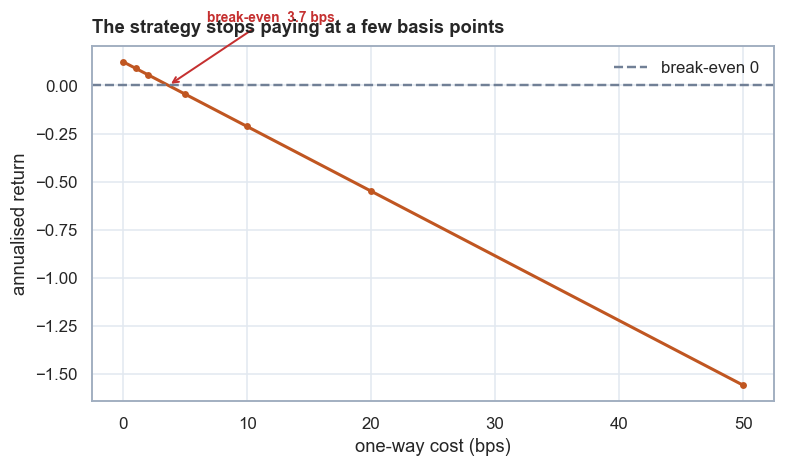

In [34]:
from rvlab.plotting import line_with_reference, annotate_point

breakeven = break_even_cost(sweep)
fig, ax = line_with_reference(sweep.set_index("cost_bps")["annualised_return"], reference=0.0,
                              reference_label="break-even",
                              title="The strategy stops paying at a few basis points",
                              xlabel="one-way cost (bps)", ylabel="annualised return")
annotate_point(ax, breakeven, 0.0, f"break-even  {breakeven:.1f} bps", dx=25, dy=40);

## R8.17 · Report three ratios, not one
<a id="r8-17"></a>

**Topic** Evaluation

**Use when** summarising any P&L. Sharpe, Sortino and Calmar penalise different things, and the gaps between them are informative.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12, R8.14

**Gotchas** **Sharpe** treats upside and downside volatility alike. **Sortino** counts only the downside — a large Sharpe-Sortino gap means the volatility is mostly good news. **Calmar** divides return by the worst drawdown, and a large Sharpe-Calmar gap means one long deep hole that Sharpe hides completely.

**See also** [R8.18](#r8-18) (the picture) · [R4.18](when_a_result_is_real.ipynb#r4-18) (tail risk)

In [35]:
from rvlab.strategy import strategy_metrics

strategy_metrics(daily["net"], turnover=daily["turnover"],
                 cost=daily["cost"]).round(4).to_frame("value")

,value
n_periods,397.0000
mean_return,0.0004
annualised_return,0.0894
annualised_vol,0.0311
sharpe,2.8743
sortino,5.1373
max_drawdown,0.0167
calmar,5.3590
hit_rate,0.5466
best,0.0057


The three ratios on deliberately different P&L shapes, so the contrasts are visible rather than asserted.

In [36]:
rng2 = np.random.default_rng(1)
shapes = {
    "steady": pd.Series(rng2.normal(0.0008, 0.004, 500)),
    "upside-skewed": pd.Series(np.r_[rng2.normal(0, 0.002, 450), rng2.normal(0.02, 0.01, 50)]),
    "one deep hole": pd.Series(np.r_[rng2.normal(0.001, 0.003, 250), [-0.25],
                                     rng2.normal(0.001, 0.003, 249)]),
}
pd.DataFrame({k: strategy_metrics(v) for k, v in shapes.items()}
             ).loc[["sharpe", "sortino", "calmar", "max_drawdown"]].round(3)

,steady,upside-skewed,one deep hole
sharpe,2.853,4.132,0.562
sortino,4.885,22.090,0.363
calmar,4.954,4.372,0.403
max_drawdown,0.033,0.104,0.258


## R8.18 · Read the tearsheet
<a id="r8-18"></a>

**Topic** Evaluation

**Use when** the standard four-panel summary: cumulative net P&L, drawdown, gross against net, and turnover.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12, R8.14

**Gotchas** the gross-versus-net panel is the one that changes decisions. Two curves diverging steadily means the strategy is being eaten by turnover, and no amount of signal improvement fixes that — only trading less does.

**See also** [R8.17](#r8-17) (the numbers) · [R7.15](seeing_and_joining_evidence.ipynb#r7-15) (the drawdown chart)

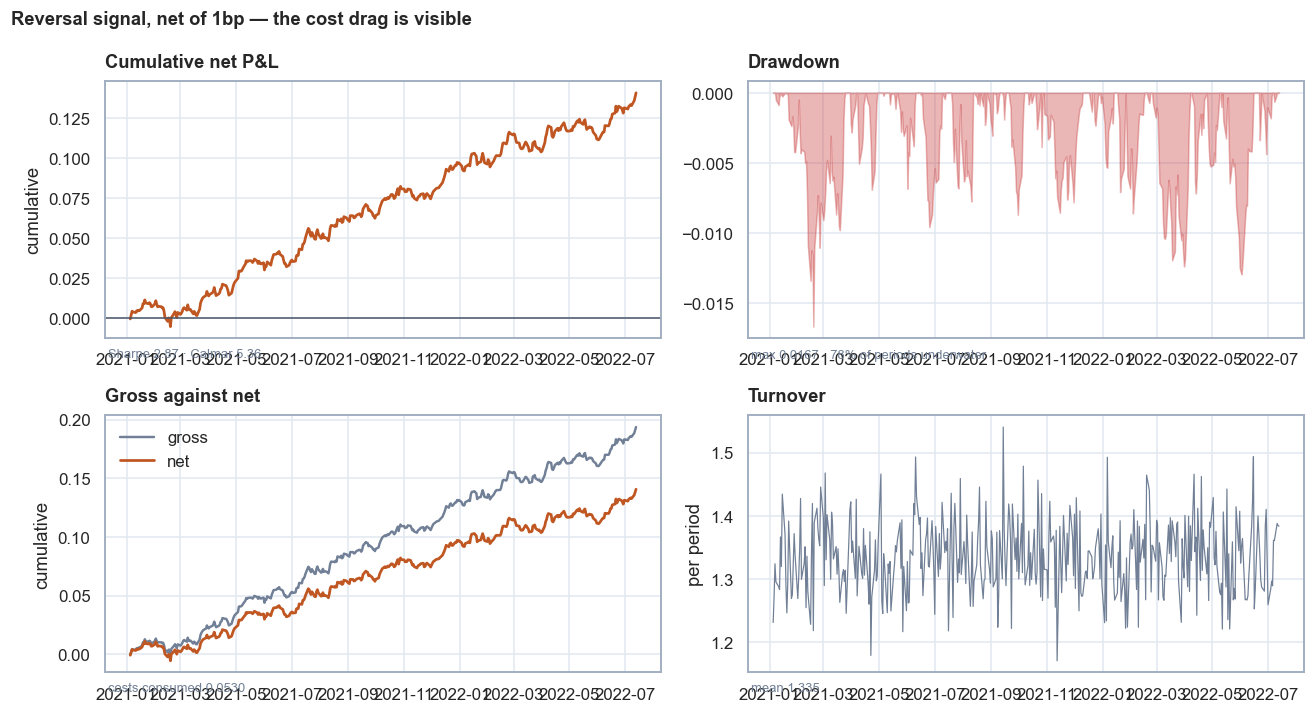

In [37]:
from rvlab.strategy import tearsheet

tearsheet(daily, title="Reversal signal, net of 1bp — the cost drag is visible");

## R8.19 · Attribute P&L to its sources
<a id="r8-19"></a>

**Topic** Attribution

**Use when** you have a P&L and need to know *where* it came from. A total is not an explanation, and a strategy earning its return from an exposure you did not intend is a strategy that will stop working without warning.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** attribution only means something if the components sum to the total. Check the identity first: a large residual is not noise, it is a term you left out, and every individual attribution is meaningless until it closes.

**See also** [R8.18](#r8-18) (the aggregate) · [R7.43](seeing_and_joining_evidence.ipynb#r7-43) (stacking the files)

In [38]:
from rvlab.config import REPO_ROOT

paths = sorted((REPO_ROOT / "demo/build/results").glob("oos_*.csv"))
greeks = ["delta_pnl", "gamma_pnl", "vega_pnl", "theta_pnl", "vanna_pnl", "volga_pnl"]

if paths:
    attribution = pd.concat([pd.read_csv(f).assign(strategy=f.stem.replace("oos_", ""))
                             for f in paths], ignore_index=True)
    by_strategy = attribution.groupby("strategy")[
        greeks + ["delta_hedge_pnl", "txn_cost", "total_pnl"]].sum()
    display(by_strategy[greeks + ["total_pnl"]].round(0))
else:
    print("demo/build/results is absent on this machine")

,delta_pnl,gamma_pnl,vega_pnl,theta_pnl,vanna_pnl,volga_pnl,total_pnl
strategy,,,,,,,
bs_delta,23418.0,27963.0,4907.0,-33976.0,-316.0,2624.0,1060036.0
bsde_is_delta,23418.0,27963.0,4907.0,-33976.0,-316.0,2624.0,885950.0
bsde_is_full,23418.0,27963.0,4907.0,-33976.0,-316.0,2624.0,284847.0
bsde_synth,23418.0,27963.0,4907.0,-33976.0,-316.0,2624.0,1060036.0
rough_delta,23418.0,27963.0,4907.0,-33976.0,-316.0,2624.0,700201.0


Now check the identity. Summing the Greek terms alone leaves most of the reported total unexplained — the exact residual share is printed below. That does not make the attribution wrong; it makes it incomplete because the hedging leg is missing.

In [39]:
if paths:
    greeks_only = by_strategy[greeks].sum(axis=1)
    residual = by_strategy["total_pnl"] - greeks_only
    display(pd.DataFrame({"greeks_only": greeks_only,
                          "reported_total": by_strategy["total_pnl"],
                          "residual_share": (residual / by_strategy["total_pnl"]).abs()
                          }).round(3))

,greeks_only,reported_total,residual_share
strategy,,,
bs_delta,24620.014,1.0600e+06,0.977
bsde_is_delta,24620.014,8.8595e+05,0.972
bsde_is_full,24620.014,2.8485e+05,0.914
bsde_synth,24620.014,1.0600e+06,0.977
rough_delta,24620.014,7.0020e+05,0.965


Adding `delta_hedge_pnl` — the P&L of the hedge itself — closes most of the gap. What remains, quantified below rather than assumed away, contains higher-order terms the decomposition does not carry.

That progression is the recipe. A large residual is not a failure of the data, it is the decomposition telling you which term you forgot.

In [40]:
if paths:
    full = by_strategy[greeks + ["delta_hedge_pnl"]].sum(axis=1)
    residual = by_strategy["total_pnl"] - full
    display(pd.DataFrame({"with_hedge_leg": full,
                          "reported_total": by_strategy["total_pnl"],
                          "residual": residual,
                          "residual_share": (residual / by_strategy["total_pnl"]).abs()
                          }).round(4))

,with_hedge_leg,reported_total,residual,residual_share
strategy,,,,
bs_delta,1.0842e+06,1.0600e+06,-24189.1487,0.0228
bsde_is_delta,9.1734e+05,8.8595e+05,-31393.3487,0.0354
bsde_is_full,3.1544e+05,2.8485e+05,-30589.3987,0.1074
bsde_synth,1.0842e+06,1.0600e+06,-24189.1487,0.0228
rough_delta,7.2323e+05,7.0020e+05,-23031.3487,0.0329


## R8.20 · Walk the strategy forward
<a id="r8-20"></a>

**Topic** Validation

**Use when** the evaluation closest to how a strategy is actually run: refit on a rolling window, trade the block that follows, roll on.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the signal function receives the training slice and the test slice separately and must return positions for the test slice only — so it cannot see beyond its own window by construction. That structural guarantee is worth more than any amount of care.

**See also** [R4.20](when_a_result_is_real.ipynb#r4-20) (walk-forward splits) · [R5.17](the_cross_section.ipynb#r5-17) (purged holdout)

In [41]:
from rvlab.strategy import signal_to_position, strategy_metrics, walk_forward_strategy

frame = panel[["Date", "Target"]].assign(score=signal.to_numpy())

def rolling_reversal(train, test):
    # Sign fitted on the training block only, applied to the test block.
    sign = np.sign(train["score"].corr(train["Target"]))
    return signal_to_position(sign * test["score"], dates=test["Date"], method="rank")

wf = walk_forward_strategy(frame, rolling_reversal, "Target", date_col="Date",
                           train_periods=120, test_periods=40, cost_bps=COST_BPS)
print(f"{wf['fold_start'].nunique()} folds · {len(wf)} scored dates")
strategy_metrics(wf["net"]).round(4).to_frame("walk-forward")

6 folds · 240 scored dates


,walk-forward
n_periods,240.0000
mean_return,0.0338
annualised_return,8.5093
annualised_vol,3.1864
sharpe,2.6705
sortino,4.8992
max_drawdown,1.2384
calmar,6.8712
hit_rate,0.5458
best,0.5673


## R8.21 · The four ways this goes wrong
<a id="r8-21"></a>

**Topic** Validation

**Use when** before reporting any result. Each of these produces a good-looking backtest and none of them raises.

**Inputs** `panel` (the feature frame with a `Target`), or the series named in the call.

**Needs** R8.12, R8.16

**Gotchas** the fourth is the hardest to see and the most common: parameters chosen by looking at the same sample you report on. Nothing in the code distinguishes it from an honest fit.

**See also** [R4.12](when_a_result_is_real.ipynb#r4-12) (in-sample selection, measured) · [R3.2](forecasting_the_smile.ipynb#r3-2) (the leak taxonomy)

In [42]:
failures = [
    ("Look-ahead in the signal", "a feature uses data from after its timestamp",
     "purged splits and grouped shifts (R3.3, R3.11–R3.12)"),
    ("Survivorship", "the universe contains only entities that still exist",
     "check entity coverage over time (R5.4)"),
    ("Cost underestimation", "costs assumed below what you would actually pay",
     "report the break-even cost, not the Sharpe (R8.16)"),
    ("In-sample parameter choice", "the window, threshold or horizon was picked on this sample",
     "an untouched holdout; measure the gap (R4.13)"),
]
pd.DataFrame(failures, columns=["failure", "what happens", "defence"])

,failure,what happens,defence
0,Look-ahead in the signal,a feature uses data from after its timestamp,"purged splits and grouped shifts (R3.3, R3.11–..."
1,Survivorship,the universe contains only entities that still...,check entity coverage over time (R5.4)
2,Cost underestimation,costs assumed below what you would actually pay,"report the break-even cost, not the Sharpe (R8..."
3,In-sample parameter choice,"the window, threshold or horizon was picked on...",an untouched holdout; measure the gap (R4.13)


The last one, demonstrated. Choosing the best cost assumption after seeing the results is a small version of the same mistake, and it flatters the strategy by a measurable amount.

In [43]:
best = sweep.loc[sweep["sharpe"].idxmax()]
honest = sweep.loc[sweep["cost_bps"] == COST_BPS].iloc[0]
print(f"best-looking cost assumption: {best['cost_bps']:.0f}bps -> Sharpe {best['sharpe']:.2f}")
print(f"the cost you actually pay   : {honest['cost_bps']:.0f}bps -> Sharpe {honest['sharpe']:.2f}")
print(f"flattery from choosing after the fact: {best['sharpe'] - honest['sharpe']:+.2f} Sharpe")

best-looking cost assumption: 0bps -> Sharpe 3.96
the cost you actually pay   : 1bps -> Sharpe 2.87
flattery from choosing after the fact: +1.08 Sharpe


## Inference, calibration, and uncertainty

What the point estimate does not tell you: how to act on a probability, how to encode without leaking, how to tune without fooling yourself, and how to quote an interval.

Its data cell binds `cat_y`, `cats`, `effect`, `ids`, `rng`.

In [44]:
import numpy as np, pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_all, y_all = make_classification(
    CLASSIFICATION_SAMPLES, n_features=14, n_informative=6, weights=[1 - POSITIVE_RATE],
    flip_y=0.02, random_state=SEED)
X_all = pd.DataFrame(X_all, columns=[f"f{i}" for i in range(X_all.shape[1])])
X, X_test, y, y_test = train_test_split(X_all, y_all, test_size=0.3,
                                        stratify=y_all, random_state=SEED)

rng = np.random.default_rng(SEED)
ids = rng.integers(0, N_CATEGORIES, CLASSIFICATION_SAMPLES)
effect = rng.normal(0, 1.5, N_CATEGORIES)
cats = pd.DataFrame({"id": ids.astype(str),
                     "x": rng.normal(size=CLASSIFICATION_SAMPLES)})
cat_y = effect[ids] + cats["x"] * 0.5 + rng.normal(0, 1.0, CLASSIFICATION_SAMPLES)

print(f"classification: {X.shape} train, positive rate {y.mean():.3f}")
print(f"categorical   : {N_CATEGORIES} levels, {CLASSIFICATION_SAMPLES:,} rows")

classification: (4200, 14) train, positive rate 0.086
categorical   : 400 levels, 6,000 rows


## R8.22 · Establish what a trivial classifier would score
<a id="r8-22"></a>

**Topic** Class imbalance

**Use when** before reporting any classification metric. On imbalanced data the majority-class baseline is high, and any accuracy at or below it is evidence of nothing.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** accuracy is the metric to stop quoting. At roughly a 9% positive rate, 'always say no' scores about 91%, and a model barely above that has demonstrated almost nothing. Balanced accuracy, ROC-AUC and average precision do not have this failure mode.

**See also** [R8.23](#r8-23) (the threshold) · [R7.25](seeing_and_joining_evidence.ipynb#r7-25) (ROC against PR)

In [45]:
from rvlab.evaluate import imbalance_report

imbalance_report(y).round(4).to_frame("value")

,value
n,4200.0000
n_classes,2.0000
positive_rate,0.0857
minority_share,0.0857
imbalance_ratio,10.6667
majority_accuracy,0.9143


Fit two models and score them the way a default workflow would, then the way it should be. `class_weight="balanced"` reweights the loss so the minority class is not simply ignored.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             accuracy_score, roc_auc_score)

models = {"plain": LogisticRegression(max_iter=2000),
          "class_weight=balanced": LogisticRegression(max_iter=2000, class_weight="balanced")}
rows = {}
for name, model in models.items():
    model.fit(X, y)
    proba = model.predict_proba(X_test)[:, 1]
    rows[name] = {"accuracy": accuracy_score(y_test, model.predict(X_test)),
                  "balanced_accuracy": balanced_accuracy_score(y_test, model.predict(X_test)),
                  "roc_auc": roc_auc_score(y_test, proba),
                  "average_precision": average_precision_score(y_test, proba)}
rows["always negative"] = {"accuracy": 1 - y_test.mean(), "balanced_accuracy": 0.5,
                           "roc_auc": 0.5, "average_precision": y_test.mean()}
pd.DataFrame(rows).T.round(4)

,accuracy,balanced_accuracy,roc_auc,average_precision
plain,0.9283,0.6724,0.8618,0.4983
class_weight=balanced,0.7983,0.7808,0.8743,0.4562
always negative,0.9144,0.5000,0.5000,0.0856


## R8.23 · Choose the threshold from what errors cost
<a id="r8-23"></a>

**Topic** Thresholds

**Use when** you must turn probabilities into decisions. 0.5 is a default, not a choice — the right cut depends on the relative cost of a false positive and a false negative.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** R8.22

**Gotchas** pick the threshold on a **validation** split, never the test set. A threshold chosen on the data you report is one more parameter fitted to it, and it flatters every metric downstream.

**See also** [R8.22](#r8-22) (imbalance) · [R8.24](#r8-24) (calibration)

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from rvlab.evaluate import best_threshold, threshold_sweep

model = LogisticRegression(max_iter=2000)
selection_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
oof_proba = cross_val_predict(model, X, y, cv=selection_cv,
                                method="predict_proba")[:, 1]
threshold_choices = pd.DataFrame([
    best_threshold(y, oof_proba, "f1"),
    best_threshold(y, oof_proba, "expected_cost", 1.0, 1.0),
    best_threshold(y, oof_proba, "expected_cost", 1.0, 10.0),
], index=["max F1", "equal costs", "a miss costs 10x"])
model.fit(X, y)
proba = model.predict_proba(X_test)[:, 1]
test_rows = [threshold_sweep(y_test, proba, thresholds=[row.threshold]).iloc[0]
             for row in threshold_choices.itertuples()]
test_evaluation = pd.DataFrame(test_rows, index=threshold_choices.index)
test_evaluation[["threshold", "precision", "recall",
                 "predicted_positive_rate"]].round(4)

,threshold,precision,recall,predicted_positive_rate
max F1,0.34,0.5873,0.4805,0.0700
equal costs,0.50,0.6437,0.3636,0.0483
a miss costs 10x,0.12,0.3220,0.6753,0.1794


The whole trade-off curve, so the choice is visible rather than asserted. Note how far the cost-weighted optimum sits from 0.5.

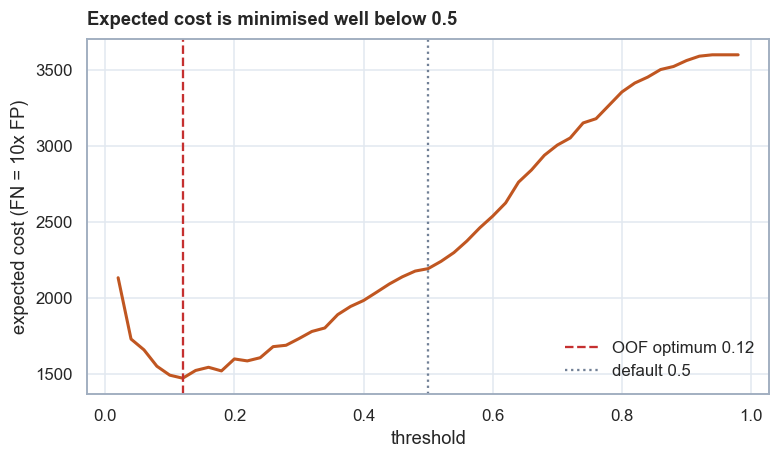

In [48]:
from rvlab.plotting import line_with_reference

sweep = threshold_sweep(y, oof_proba, cost_false_negative=10.0)
fig, ax = line_with_reference(sweep.set_index("threshold")["expected_cost"],
                              reference=None, marker="",
                              title="Expected cost is minimised well below 0.5",
                              xlabel="threshold", ylabel="expected cost (FN = 10x FP)")
chosen = threshold_choices.loc["a miss costs 10x", "threshold"]
ax.axvline(chosen, color="#c53030", ls="--", lw=1.5,
           label=f"OOF optimum {chosen:.2f}")
ax.axvline(0.5, color="#718096", ls=":", lw=1.5, label="default 0.5")
ax.legend();

## R8.24 · Check calibration, not just ranking
<a id="r8-24"></a>

**Topic** Calibration

**Use when** you will act on the predicted probability rather than the ordering — sizing a position, computing an expected value, setting a cost-weighted threshold.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** R8.23

**Gotchas** the **calibration slope** must be measured with a logistic link, not a linear one: a linear fit returns probability-per-logit units that are never near 1 and cannot be read against the perfect-calibration value. Slope below 1 means overconfident, which is the usual direction for a boosted tree.

**See also** [R8.23](#r8-23) (thresholds) · [R7.24](seeing_and_joining_evidence.ipynb#r7-24) (the curve)

In [49]:
from sklearn.ensemble import HistGradientBoostingClassifier
from rvlab.evaluate import calibration_report

boosted = HistGradientBoostingClassifier(max_iter=250, random_state=SEED).fit(X, y)
proba_boosted = boosted.predict_proba(X_test)[:, 1]

pd.DataFrame({"logistic": calibration_report(y_test, proba),
              "boosted": calibration_report(y_test, proba_boosted)}).round(4)

,logistic,boosted
brier,0.0563,0.0334
roc_auc,0.8618,0.9341
expected_calibration_error,0.0124,0.0207
calibration_slope,0.8688,0.4016
calibration_intercept,-0.2103,0.2123
mean_predicted,0.0855,0.0643
observed_rate,0.0856,0.0856


The boosted model ranks better (higher ROC-AUC) and is **worse calibrated** — a combination that is entirely normal and that AUC alone cannot reveal. `CalibratedClassifierCV` fixes it by fitting a correction on held-out folds.

In [50]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(
    HistGradientBoostingClassifier(max_iter=250, random_state=SEED),
    method="isotonic", cv=4).fit(X, y)
proba_calibrated = calibrated.predict_proba(X_test)[:, 1]

pd.DataFrame({"boosted": calibration_report(y_test, proba_boosted),
              "boosted + isotonic": calibration_report(y_test, proba_calibrated)}
             ).loc[["brier", "roc_auc", "calibration_slope",
                    "expected_calibration_error"]].round(4)

,boosted,boosted + isotonic
brier,0.0334,0.0316
roc_auc,0.9341,0.9341
calibration_slope,0.4016,0.9153
expected_calibration_error,0.0207,0.0066


## R8.25 · Target-encode inside the folds, never across them
<a id="r8-25"></a>

**Topic** Encoding

**Use when** you have a high-cardinality categorical. Target encoding is the strongest tool for it and the easiest to get catastrophically wrong.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** computed on the whole training set it **leaks the target into the feature**: a category appearing once takes that row's own label as its encoding, and the model reads the answer off its own input. The demonstration below uses a **random** target, where the correct answer is exactly zero skill.

**See also** [R8.26](#r8-26) (rare levels) · [R3.4](forecasting_the_smile.ipynb#r3-4) (fitting inside a pipeline)

In [51]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from rvlab.features import CVTargetEncoder

noise_target = rng.normal(size=CLASSIFICATION_SAMPLES)  # no relationship to `id`
ids_only = cats[["id"]]

leaky = ids_only.assign(
    enc=pd.Series(noise_target).groupby(cats["id"]).transform("mean"))[["enc"]]
outer_encoding_cv = KFold(5, shuffle=True, random_state=SEED + 1)
safe_model = Pipeline([
    ("encode", CVTargetEncoder(columns=["id"], cv=5, random_state=SEED)),
    ("model", Ridge()),
])

print(f"naive full-sample encoding : CV R2 = "
      f"{cross_val_score(Ridge(), leaky, noise_target, cv=outer_encoding_cv).mean():+.4f}")
print(f"encoder fitted inside outer folds: CV R2 = "
      f"{cross_val_score(safe_model, ids_only, noise_target, cv=outer_encoding_cv).mean():+.4f}")

naive full-sample encoding : CV R2 = +0.0640
encoder fitted inside outer folds: CV R2 = -0.0015


> ⚠️ **Leakage:** the target was pure noise. The naive encoding still produces a confident positive R², because each row's feature contains its own label. Nothing warns you — the model simply reports skill it does not have.\n\nThe pipeline-safe version refits its encoder inside every outer fold. On a synthetic target with a planted category effect it still recovers that signal.

In [52]:
signal_model = Pipeline([
    ("encode", CVTargetEncoder(columns=["id"], cv=5, random_state=SEED)),
    ("model", Ridge()),
])
print(f"planted category effect, encoder fitted inside outer folds: CV R2 = "
      f"{cross_val_score(signal_model, cats, cat_y, cv=outer_encoding_cv).mean():+.4f}")

planted category effect, encoder fitted inside outer folds: CV R2 = +0.6521


## R8.26 · Handle rare and unseen categories
<a id="r8-26"></a>

**Topic** Encoding

**Use when** before one-hot encoding anything high-cardinality. Levels seen a handful of times produce near-empty dummies, and levels that appear only at prediction time break the encoder.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** R8.25

**Gotchas** grouping rare levels into one bucket solves both at once: fewer columns, and an `__rare__` level the model has actually been trained on. Frequency encoding is the other cheap option and cannot leak, because it never touches the target.

**See also** [R8.25](#r8-25) (target encoding) · [R6.19](where_the_numbers_come_from.ipynb#r6-19) (measuring cardinality)

In [53]:
from rvlab.features import FrequencyEncoder, RareCategoryGrouper

grouper = RareCategoryGrouper(columns=["id"], min_frequency=0.004).fit(cats)
grouped = grouper.transform(cats)
print(f"{cats['id'].nunique()} levels -> {grouped['id'].nunique()} after grouping")
print(f"unseen level maps to: "
      f"{grouper.transform(pd.DataFrame({'id': ['brand_new']}))['id'].iloc[0]!r}")

400 levels -> 7 after grouping
unseen level maps to: '__rare__'


Frequency encoding as the leak-free alternative — how common a category is often carries real information, and it uses no labels at all.

In [54]:
freq = FrequencyEncoder(columns=["id"]).fit_transform(cats[["id"]])
print(f"frequency encoding range: {freq['id'].min():.5f} to {freq['id'].max():.5f}")
print(f"CV R2 on the planted signal-bearing target: "
      f"{cross_val_score(Ridge(), freq, cat_y, cv=5).mean():+.4f}  "
      "(weaker than target encoding, but structurally incapable of leaking)")

frequency encoding range: 0.00067 to 0.00450
CV R2 on the planted signal-bearing target: -0.0034  (weaker than target encoding, but structurally incapable of leaking)


## R8.27 · Encode periodic features as a sine/cosine pair
<a id="r8-27"></a>

**Topic** Encoding

**Use when** month, weekday, hour — anything circular. An integer encoding tells the model December and January are eleven apart.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** two columns are required, not one. A single sine collides — it gives the same value for two different points in the cycle — and the pair is what makes every pairwise distance come out right.

**See also** [R8.26](#r8-26) (categoricals) · [R5.7](the_cross_section.ipynb#r5-7) (calendar features)

In [55]:
from rvlab.features import CyclicalEncoder

months = pd.DataFrame({"month": [12, 1, 6]})
encoded = CyclicalEncoder({"month": 12}).fit_transform(months)

distance = lambda i, j: float(np.hypot(encoded["month_sin"].iloc[i] - encoded["month_sin"].iloc[j],
                                       encoded["month_cos"].iloc[i] - encoded["month_cos"].iloc[j]))
print(f"December to January : {distance(0, 1):.3f}   (integers say 11 apart)")
print(f"December to June    : {distance(0, 2):.3f}   (integers say 6 apart)")
encoded.round(3)

December to January : 0.518   (integers say 11 apart)
December to June    : 2.000   (integers say 6 apart)


,month_sin,month_cos
0,-0.0,1.000
1,0.5,0.866
2,0.0,-1.000


## R8.28 · Nest the cross-validation when you tune
<a id="r8-28"></a>

**Topic** Model selection

**Use when** you tune hyperparameters and then report the cross-validated score. A single CV loop that does both reports an optimistically biased number.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** the inner loop selects, the outer loop evaluates, and the outer folds never influence the selection. The bias is small with a two-point grid and large with a wide one — it grows with how hard you searched.

**See also** [R8.29](#r8-29) (a bigger search) · [R3.13](forecasting_the_smile.ipynb#r3-13) (the single loop)

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

grid = {"C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
inner = StratifiedKFold(4, shuffle=True, random_state=SEED)
outer = StratifiedKFold(4, shuffle=True, random_state=SEED + 1)
search = GridSearchCV(LogisticRegression(max_iter=2000), grid, cv=inner,
                      scoring="average_precision")

flat = search.fit(X, y).best_score_
nested = cross_val_score(search, X, y, cv=outer, scoring="average_precision").mean()
print(f"single-loop (tuned and scored together): {flat:.4f}")
print(f"nested      (selection inside, scored outside): {nested:.4f}")
print(f"optimism from scoring on the selection loop: {flat - nested:+.4f}")

single-loop (tuned and scored together): 0.5763
nested      (selection inside, scored outside): 0.5723
optimism from scoring on the selection loop: +0.0040


## R8.29 · Search a large space with Optuna
<a id="r8-29"></a>

**Topic** Model selection

**Use when** the grid has more than two or three dimensions. A grid's cost is multiplicative; a sampler's is not, and Optuna concentrates its budget where the score is improving.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** R8.28 — run those first. This recipe builds on what they define.

**Gotchas** give it the **same** inner cross-validation the grid would have used, or the comparison is meaningless, then evaluate the selected trial once on an outer set held out from this search. A sampler's result is stochastic — fix the seed, and do not read a small improvement over a grid as evidence the sampler is better.

**See also** [R8.28](#r8-28) (nesting) · [R3.14](forecasting_the_smile.ipynb#r3-14) (randomised search)

In [57]:
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

inner = StratifiedKFold(4, shuffle=True, random_state=SEED)

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    model = HistGradientBoostingClassifier(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 4, 63),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 200, log=True),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
        max_iter=100, random_state=SEED)
    return cross_val_score(model, X, y, cv=inner, scoring="average_precision").mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
best_model = HistGradientBoostingClassifier(
    **study.best_params, max_iter=100, random_state=SEED).fit(X, y)
holdout_ap = average_precision_score(y_test, best_model.predict_proba(X_test)[:, 1])
print(f"inner-CV average precision {study.best_value:.4f} after {N_TRIALS} trials")
print(f"search-held-out average precision {holdout_ap:.4f}")
print({k: round(v, 4) if isinstance(v, float) else v
       for k, v in study.best_params.items()})

inner-CV average precision 0.8230 after 12 trials
search-held-out average precision 0.7798
{'learning_rate': 0.2565, 'max_leaf_nodes': 37, 'min_samples_leaf': 10, 'l2_regularization': 5.9629}


Which parameters actually mattered. Optuna's importances are computed over the trials it ran, so they answer 'what moved the score in this search' rather than 'what matters in general' — but that is usually the question.

In [58]:
importances = optuna.importance.get_param_importances(study)
pd.Series(importances, name="importance").to_frame().round(4)

,importance
learning_rate,0.4909
max_leaf_nodes,0.2553
min_samples_leaf,0.2501
l2_regularization,0.0037


## R8.30 · Predict an interval, not a point
<a id="r8-30"></a>

**Topic** Uncertainty

**Use when** a point forecast is not enough — you need to size a position, set a reserve, or say how confident the model is. Quantile regression predicts the conditional quantiles directly.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** nothing beyond the setup and data cells

**Gotchas** fit one model per quantile, and check **coverage** on held-out data: a 90% interval should contain the outcome about 90% of the time. Quantile crossing (the 10% prediction above the 90%) is possible with separate fits and is a sign the model is under-constrained.

**See also** [R8.31](#r8-31) (what it is not) · [R3.19](forecasting_the_smile.ipynb#r3-19) (bootstrap intervals)

In [59]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(cats[["x"]], cat_y, test_size=0.3,
                                              random_state=SEED)
quantiles = {}
for q in (0.05, 0.5, 0.95):
    quantiles[q] = GradientBoostingRegressor(
        loss="quantile", alpha=q, n_estimators=200, max_depth=3,
        random_state=SEED).fit(Xc_tr, yc_tr).predict(Xc_te)

inside = ((yc_te >= quantiles[0.05]) & (yc_te <= quantiles[0.95])).mean()
print(f"nominal coverage 90% · empirical coverage {inside:.1%}")
print(f"quantile crossing (5% above 95%): {(quantiles[0.05] > quantiles[0.95]).sum()} rows")

nominal coverage 90% · empirical coverage 88.3%
quantile crossing (5% above 95%): 0 rows


The interval, plotted against the outcome. Its *width* is the useful output: it widens where the model is uncertain, which a point forecast cannot express.

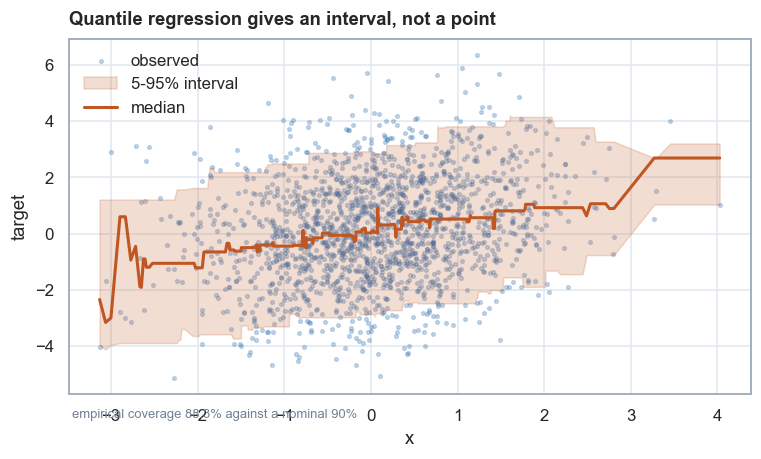

In [60]:
import matplotlib.pyplot as plt
from rvlab.plotting import finish

order = np.argsort(Xc_te["x"].to_numpy())
xs = Xc_te["x"].to_numpy()[order]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(xs, np.asarray(yc_te)[order], s=6, alpha=0.25, color="#2b6cb0", label="observed")
ax.fill_between(xs, quantiles[0.05][order], quantiles[0.95][order],
                color="#c05621", alpha=0.2, label="5-95% interval")
ax.plot(xs, quantiles[0.5][order], color="#c05621", lw=2, label="median")
ax.legend()
finish(ax, "Quantile regression gives an interval, not a point", "x", "target",
       f"empirical coverage {inside:.1%} against a nominal 90%");

## R8.31 · Know which uncertainty you measured
<a id="r8-31"></a>

**Topic** Uncertainty

**Use when** reporting any interval. There are two, they answer different questions, and conflating them is the most common mistake in this area.

**Inputs** `X`, `y` and the frames named in the call.

**Needs** R8.30

**Gotchas** a **prediction interval** covers where the next observation will fall and includes irreducible noise. A **confidence interval on the mean** covers where the average sits and shrinks toward zero with more data. Quantile regression gives you the first; a bootstrap of the fitted mean gives you the second. Measure the ratio: here it is dozens-fold.

**See also** [R8.30](#r8-30) (prediction intervals) · [R3.19](forecasting_the_smile.ipynb#r3-19) (block bootstrap)

In [61]:
from sklearn.linear_model import LinearRegression

prediction_width = float(np.mean(quantiles[0.95] - quantiles[0.05]))

boot = []
rng_boot = np.random.default_rng(SEED)
for _ in range(200):
    idx = rng_boot.integers(0, len(Xc_tr), len(Xc_tr))
    fit = LinearRegression().fit(Xc_tr.iloc[idx], np.asarray(yc_tr)[idx])
    boot.append(fit.predict(Xc_te.iloc[[0]])[0])
mean_width = float(np.percentile(boot, 97.5) - np.percentile(boot, 2.5))

print(f"90% prediction interval width (next observation) : {prediction_width:.3f}")
print(f"95% confidence interval width (the mean)         : {mean_width:.3f}")
print(f"ratio: {prediction_width / mean_width:.0f}x — "
      "quoting the second when you meant the first understates risk badly")

90% prediction interval width (next observation) : 5.774
95% confidence interval width (the mean)         : 0.114
ratio: 51x — quoting the second when you meant the first understates risk badly


## Verdict & what carries forward

Measurement, then position, then the honest statement of what is still unknown.

### Measuring and forecasting volatility

Volatility measured five ways, modelled three ways, and forecast against the benchmark that
matters. What carries forward:

* **The estimator choice moves the answer by 25%.** The three pure-range estimators land
  around 0.72 of close-to-close on this data and Yang-Zhang around 0.94 — not because three
  of them are wrong, but because only one models the overnight gap. Quote which estimator you
  used.
* **They are biased *and* precise.** [R8.2](#r8-2) measures the efficiency gain properly —
  roughly four to eight times, by resampling one process rather than comparing across assets — and
  [R8.3](#r8-3) shows the bias shrinking as the bar is sampled more finely. That is the real
  trade, and it favours range estimators at short horizons.
* **Persistence alone is not clustering.** [R8.11](#r8-11) reports absolute-return
  autocorrelation and a stressed-to-calm ratio beside GARCH persistence and a null control.
  A persistence near one on non-clustering synthetic data is the warning: no single fitted
  coefficient establishes forecastability.
* **The variance risk premium's sign is measured, not assumed.** [R8.10](#r8-10) reports
  implied minus subsequent realized variance and its left tail. A negative sample does not
  establish the usual positive-premium claim; a positive one is not a free lunch.

Next in this notebook: **From model to position** — turning
any of this into a position, and finding out what it costs.

### From model to position

The machinery from score to net P&L, with the decisions that matter made explicitly:

* **Ranking beats z-scoring for a cross-sectional book.** [R8.12](#r8-12) plants one absurd
  score: it moves a handful of ranked positions and distorts the entire z-scored book.
* **Standardise within the date.** [R8.13](#r8-13) shows the pooled version is not a worse
  version of the same strategy — it is a different strategy, with different volatility and a
  different drawdown.
* **Costs decide it.** At a realistic signal strength the break-even cost is a few basis
  points. That is the number to report, not the Sharpe at whatever cost you assumed — and it
  is why turnover is a design constraint rather than an output.
* **Three ratios, because they disagree usefully.** [R8.17](#r8-17) shows one deep drawdown
  damaging both Sharpe and Calmar, with Calmar falling much more severely.

And a note on the signal: it was deliberately degraded to a rank IC of +0.017, because the
planted effect at full strength yields a Sharpe near 17 and survives every cost level. A
backtest that cannot be killed by costs is not demonstrating a strategy, it is demonstrating
a leak or a simulation.

Next in this notebook: **Inference, calibration, and uncertainty**.

### Inference, calibration, and uncertainty

The gaps, closed. Four results worth carrying:

* **Accuracy is not a metric on imbalanced data.** At roughly a 9% positive rate the trivial
  classifier scores about 91%; anything near that has demonstrated nothing. Report balanced
  accuracy and average precision, whose baseline is the positive rate.
* **Naive target encoding leaks, provably.** [R8.25](#r8-25) encodes a **random** target and
  the full-sample version still produces a confident positive cross-validated R². The
  out-of-fold encoder returns approximately zero, which is the correct answer. Nothing about
  the leaky version looks wrong from the outside.
* **Ranking well and being calibrated are different properties.** The boosted model beats
  logistic regression on ROC-AUC and is markedly worse calibrated — normal, invisible to AUC,
  and fatal if you act on the probability rather than the ordering.
* **Two uncertainties, dozens-fold apart here.** A prediction interval and a confidence
  interval on the mean answer different questions ([R8.31](#r8-31)). Quoting the narrow one
  where the wide one belongs understates risk by a factor you can measure.

---

That closes Part III. Part IV, the [Competition Workbench](competition_workbench.ipynb),
turns the method into a reusable structured-data template. Across all four parts, the
methodology is the through-line — a claim, an estimator, a validation scheme chosen for the
leak you are most exposed to, a metric that matches the decision, and an economic test at the
end. Rough volatility is the hypothesis it was demonstrated on; the sequence outlives it.

For reference use, the [index](README.md) is the entry point: search a technique or a topic,
land on a runnable cell. Next: [Competition Workbench](competition_workbench.ipynb).